In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [6]:
import os
os.getcwd()
os.listdir()

['.gitignore',
 '.ipynb_checkpoints',
 'app.py',
 'EDA CHURN.ipynb',
 'notebook',
 'requirements.txt',
 'src',
 'templates',
 'venv']

In [7]:
os.listdir('notebook')

['data']

In [9]:
data = pd.read_csv('notebook/data/churn2.csv')

In [10]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [16]:
data["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [28]:
data["Exited"].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [18]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [26]:
data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [27]:
data.duplicated().sum()

np.int64(0)

#### Numeric Distributions

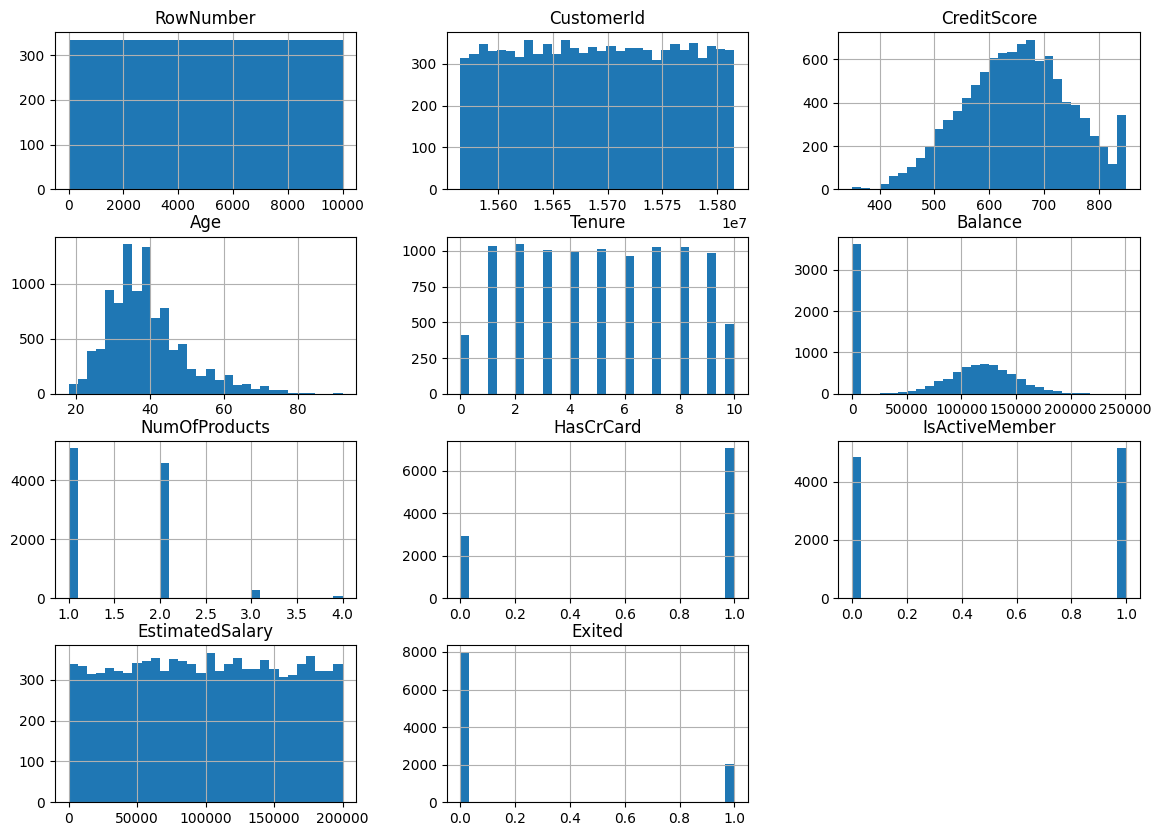

In [31]:
data.hist(bins=30, figsize=(14,10))
plt.show()

#### Categorical Counts

In [32]:
for col in ["Geography", "Gender", "HasCrCard", "IsActiveMember", "NumOfProducts"]:
    print(data[col].value_counts())

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Gender
Male      5457
Female    4543
Name: count, dtype: int64
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


#### Churn rate by Categorical Features

In [29]:
for col in ['Geography', 'Gender', 'IsActiveMember', 'HasCrCard', 'NumOfProducts', 'Tenure']:
    print(f"--- {col} ---")
    print(data.groupby(col)['Exited'].mean().sort_values(ascending=False))

--- Geography ---
Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64
--- Gender ---
Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64
--- IsActiveMember ---
IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64
--- HasCrCard ---
HasCrCard
0    0.208149
1    0.201843
Name: Exited, dtype: float64
--- NumOfProducts ---
NumOfProducts
4    1.000000
3    0.827068
1    0.277144
2    0.075817
Name: Exited, dtype: float64
--- Tenure ---
Tenure
0     0.230024
1     0.224155
9     0.216463
3     0.211100
5     0.206522
10    0.206122
4     0.205258
6     0.202689
8     0.192195
2     0.191794
7     0.172179
Name: Exited, dtype: float64


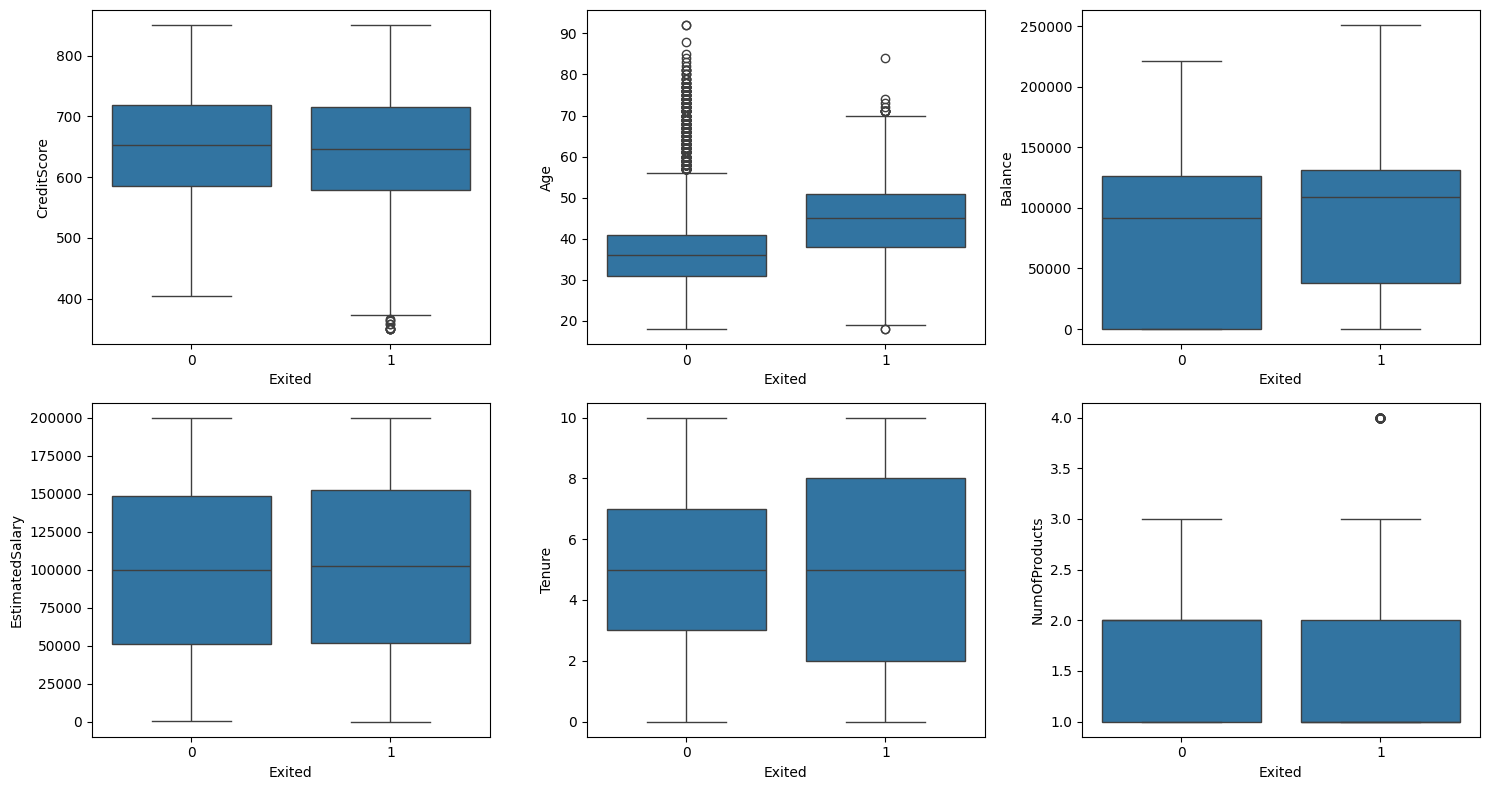

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
for ax, col in zip(axes.flat, ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure', 'NumOfProducts']):
    sns.boxplot(x='Exited', y=col, data=data, ax=ax)
plt.tight_layout()
plt.show()
    

#### Correlation Analysis

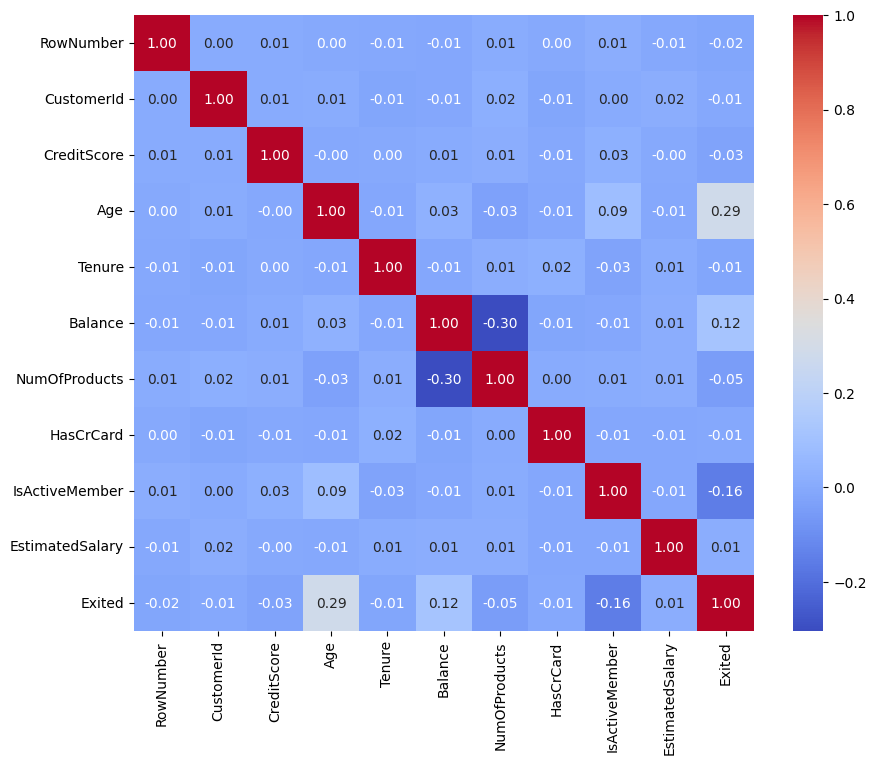

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

#### Derived Checks

#### Zero-balance segment

In [36]:
data['has_zero_balance'] = (data['Balance'] == 0)
data.groupby('has_zero_balance')['Exited'].mean()

has_zero_balance
False    0.240796
True     0.138236
Name: Exited, dtype: float64

#### Age bins - Reveals threshold effect

In [40]:
data['age_group'] = pd.cut(data['Age'], bins=[18,30,40,50,60,92])
data.groupby(['has_zero_balance', 'age_group'])['Exited'].mean()

has_zero_balance  age_group
False             (18, 30]     0.098818
                  (30, 40]     0.144080
                  (40, 50]     0.387875
                  (50, 60]     0.600000
                  (60, 92]     0.306397
True              (18, 30]     0.038058
                  (30, 40]     0.081360
                  (40, 50]     0.245547
                  (50, 60]     0.477733
                  (60, 92]     0.143713
Name: Exited, dtype: float64

#### Balance to salary ratio

<Axes: xlabel='Exited', ylabel='balance_salary_ratio'>

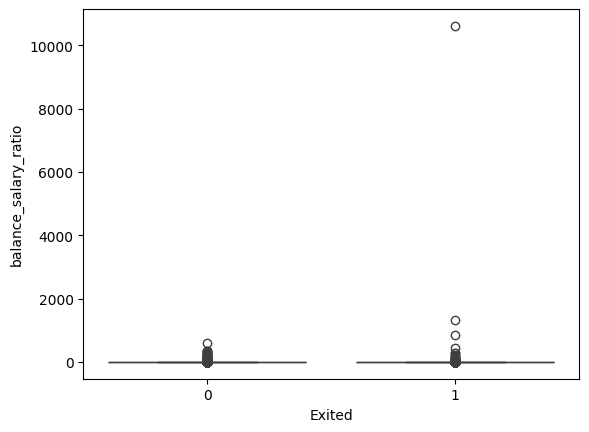

In [38]:
data['balance_salary_ratio'] = data['Balance'] / data['EstimatedSalary']
sns.boxplot(x='Exited', y='balance_salary_ratio', data=data)

#### Multivariate view

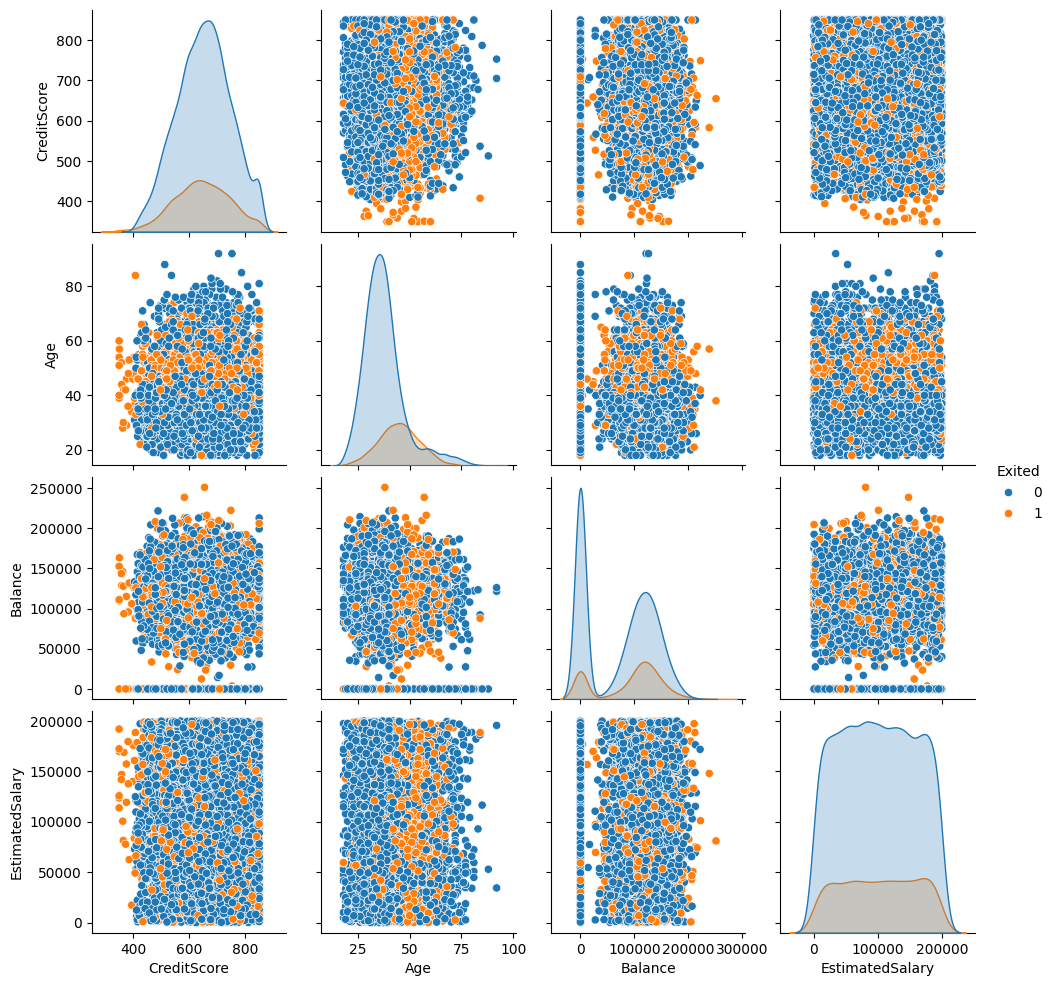

In [39]:
sns.pairplot(data[['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Exited']], hue='Exited', diag_kind='kde')
